In [63]:
import warnings
warnings.filterwarnings(action='ignore')

In [64]:
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df = pd.read_csv('titanic_toy.csv')
df = df.loc[:,['Age', 'Fare', 'Survived']]

In [66]:
df.head(5)

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [67]:
print('Total no. of missing values')
print('-'*30)
print(df.isnull().sum()) 
print()
print('Avg. missing values')
print('-'*30)
print(df.isnull().mean()*100)

Total no. of missing values
------------------------------
Age         177
Fare         45
Survived      0
dtype: int64

Avg. missing values
------------------------------
Age         19.865320
Fare         5.050505
Survived     0.000000
dtype: float64


In [68]:
X, y = df.iloc[:,:-1], df.iloc[:,-1]

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
X_train['Age_Imputed'] = X_train['Age']
X_test['Age_Imputed'] = X_test['Age']

In [71]:
X_train['Age_Imputed'][X_train['Age_Imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_Imputed'][X_test['Age_Imputed'].isnull()] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [72]:
X_train.sample(10) # Missing values in 'Age_Imputed' col are now Imputed with Random-Values from 'Age' col.

,Age,Fare,Age_Imputed
495,NaN,14.4583,19.0
610,39.0,31.2750,39.0
324,NaN,69.5500,22.0
62,45.0,83.4750,45.0
4,35.0,8.0500,35.0
770,24.0,9.5000,24.0
293,24.0,8.8500,24.0
689,15.0,211.3375,15.0
88,23.0,263.0000,23.0
265,36.0,10.5000,36.0


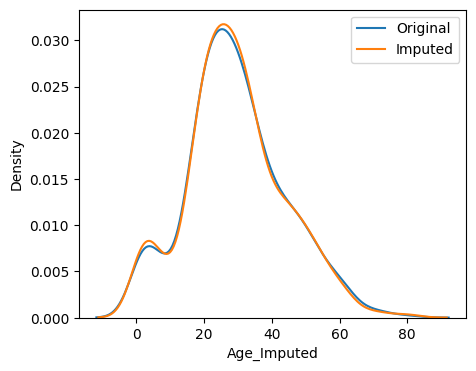

In [73]:
plt.figure(figsize=(5, 4))

sns.distplot(X_train['Age'], label='Original',  hist=False)
sns.distplot(X_train['Age_Imputed'], label='Imputed',  hist=False)

plt.legend()
plt.show()

In [74]:
print('Original Variance:', X_train['Age'].var())
print('Variance after Random value Imputation:', X_train['Age_Imputed'].var())

Original Variance: 210.2517072477435
Variance after Random value Imputation: 208.2175090375559


In [75]:
X_train[['Fare', 'Age', 'Age_Imputed']].cov()

,Fare,Age,Age_Imputed
Fare,2761.031435,75.481375,64.840373
Age,75.481375,210.251707,210.251707
Age_Imputed,64.840373,210.251707,208.217509


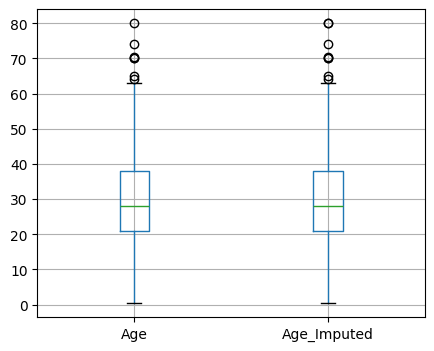

In [76]:
plt.figure(figsize=(5, 4))
X_train[['Age', 'Age_Imputed']].boxplot()
plt.show()

In [77]:
data = pd.read_csv('train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
data.head(5)

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [78]:
print('Total no. of missing values')
print('-'*30)
print(data.isnull().sum()) 
print()
print('Avg. missing values')
print('-'*30)
print(data.isnull().mean()*100)

Total no. of missing values
------------------------------
FireplaceQu    690
GarageQual      81
SalePrice        0
dtype: int64

Avg. missing values
------------------------------
FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64


In [79]:
X, y = data.iloc[:,:-1], data.iloc[:,-1]

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
X_train['GarageQual_Imputed'] = X_train['GarageQual']
X_test['GarageQual_Imputed'] = X_test['GarageQual']

X_train['FireplaceQu_Imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_Imputed'] = X_test['FireplaceQu']

In [82]:
X_train['FireplaceQu_Imputed'][X_train['FireplaceQu_Imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_Imputed'][X_test['FireplaceQu_Imputed'].isnull()] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

X_train['GarageQual_Imputed'][X_train['GarageQual_Imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_Imputed'][X_test['GarageQual_Imputed'].isnull()] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

In [83]:
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_Imputed'].value_counts() / len(X_train)
    ],
    axis=1)
temp.columns = ['Original', 'Imputed']
temp

,Original,Imputed
TA,0.951087,0.952055
Fa,0.032609,0.032534
Gd,0.011775,0.011130
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [92]:
temp = pd.concat(
    [
        X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
        X_train['FireplaceQu_Imputed'].value_counts() / len(X_train)
    ],
    axis=1)
temp.columns = ['Original', 'Imputed']
temp

,Original,Imputed
Gd,0.491143,0.498288
TA,0.405797,0.400685
Fa,0.043478,0.042808
Ex,0.033816,0.033390
Po,0.025765,0.024829
